# 09 - DA method comparison (pixel vs latent, and future methods)

Method-agnostic head-to-head. It globs every `outputs/da/*/metrics.csv`, so any method
that writes the shared schema (the tuned pixel 3DVar, the latent PCA/AE/VAE runs, and
later EnKF or the generative prior) appears here with no new code. A `model` label
distinguishes the tuned pixel model, the latent representations, and the naive baselines.

Two lanes are reported: the same-model PPE, where a full field truth exists, and the
real-proxy withholding lane, where only the withheld sites are scored.

Each algorithm is reported at its **own selected operating point**: the pixel model tunes
its regularization (localization / shrinkage / alpha) jointly with `b_scale` on the
held-out `selection` split; the others select `b_scale` alone. Scoring is on the disjoint
`test` split (no in-sample optimism, no fixed `b_scale=1`). The sweep is shown alongside
so the sensitivity is visible. All skill is anomaly-space (CE/RMSE/correlation are
shift-invariant); read latent skill against each compressor's reconstruction floor from
notebook 08.

Skill answers how wrong a reconstruction is; the calibration block below answers whether
it knew, which is the axis a Gaussian and a generative posterior actually differ on. The
withholding CE is small by construction and must be read against the prior-free
`nearest` / `idw` rows, not against 1.

In [1]:
import glob
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
from paleoreco.data import VARS
from paleoreco.eval import da
from paleoreco.assim import experiments as ex
from paleoreco.assim.innovation import nearest_lat_index, nearest_lon_index

plt.rcParams["figure.dpi"] = 110
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/09_da_comparison"); FIG.mkdir(parents=True, exist_ok=True)

TAPER = ["localization_km", "shrinkage_lambda", "alpha"]

M = pd.concat([pd.read_csv(p) for p in glob.glob(str(OUT / "*/metrics.csv"))],
              ignore_index=True)
# One label per reconstructor: naive keeps its method; 3dvar keeps its space (pixel/latent).
M["model"] = np.where(M.method != "3dvar", M.method, M.space)

# The naive baselines are prior-free, so every runner writes an identical copy; collapse
# duplicates. The taper columns are in the key so distinct pixel-grid configs survive
# (drop_duplicates treats NaN as equal, so naive's NaN taper still dedups to one).
M = M.drop_duplicates(
    subset=["model", "lane", "split", "fold", "do_event", "channel", "metric", "b_scale"] + TAPER,
    keep="first").reset_index(drop=True)

LANES = ["ppe", "withholding_random"]
ROW_ORDER = ["pixel", "pca", "ae", "vae", "idw", "nearest"]
MODEL_DIR = {"pixel": "3dvar_pixel", "pca": "3dvar_pca", "ae": "3dvar_ae", "vae": "3dvar_vae"}


def best_config(model, lane):
    """Selected {taper + b_scale} for (model, lane) via the shared prefer-simpler rule.

    Pixel selects over the whole taper grid; latent over its single config's b_scale; the
    prior-free naive baselines have no selection split and return their only b_scale.
    """
    sub = M[(M.model == model) & (M.lane == lane) & (M.split == "selection")
            & (M.channel == "pooled") & (M.do_event == "all") & (M.metric == "rrmse")]
    if not sub.empty:
        return ex.select_best_config(sub)
    b = M[(M.model == model) & (M.lane == lane)]["b_scale"]
    return {"localization_km": np.nan, "shrinkage_lambda": np.nan, "alpha": np.nan,
            "b_scale": float(b.iloc[0]) if len(b) else 1.0}


def match_taper(sub, cfg):
    """Rows of ``sub`` at the selected taper config (any b_scale)."""
    keep = np.ones(len(sub), bool)
    for col in TAPER:
        v = cfg[col]
        colv = sub[col].to_numpy(dtype=float)
        off = v is None or (isinstance(v, float) and np.isnan(v))
        keep = keep & (np.isnan(colv) if off else np.isclose(colv, v))
    return sub[keep]


def match_config(sub, cfg):
    """Rows of ``sub`` at the selected taper config and its b_scale."""
    sub = match_taper(sub, cfg)
    return sub[np.isclose(sub["b_scale"].to_numpy(dtype=float), cfg["b_scale"])]


print("models:", sorted(M.model.unique()))
print("lanes:", sorted(M.lane.unique()), "| splits:", sorted(M.split.dropna().unique()))

models: ['ae', 'idw', 'nearest', 'pca', 'pixel', 'vae']
lanes: ['ppe', 'withholding_random'] | splits: ['selection', 'test']


## Selected operating point per (model, lane)

For each algorithm and lane, the operating point minimises the pooled RRMSE on the
**selection** split. For the pixel model this is a joint (localization, shrinkage, alpha,
b_scale) choice (prefer-simpler within tolerance), so its winning taper config differs by
lane; the others select `b_scale` alone. These are the points the summary and gallery
report at.

In [2]:
best = {(m, lane): best_config(m, lane) for m in ROW_ORDER for lane in LANES}

# Selected b_scale* per (model, lane).
bs_tab = pd.DataFrame({lane: {m: best[(m, lane)]["b_scale"] for m in ROW_ORDER} for lane in LANES})
print("Selected b_scale* per (model, lane):")
display(bs_tab.reindex(ROW_ORDER)[LANES])

# The 'pixel' row is one tuned taper config per lane; surface which one.
pix = pd.DataFrame({lane: {k: best[("pixel", lane)][k]
                           for k in ["localization_km", "shrinkage_lambda", "alpha", "b_scale"]}
                    for lane in LANES})
print("Selected pixel taper config per lane:")
display(pix[LANES])

Selected b_scale* per (model, lane):


,ppe,withholding_random
pixel,2.0,1.0
pca,0.3,0.5
ae,0.1,0.5
vae,0.1,0.5
idw,1.0,1.0
nearest,1.0,1.0


Selected pixel taper config per lane:


,ppe,withholding_random
localization_km,15000.00,NaN
shrinkage_lambda,0.00,0.5
alpha,0.25,0.5
b_scale,2.00,1.0


## Master summary: each model at its own b_scale*

Test-split metrics evaluated at the selected `b_scale*` per (model, lane). PPE carries
SSIM (a full field exists); the point lanes do not. Pooled channel; per-channel
breakouts below.

In [3]:
def summary_table(channel="pooled"):
    rows = {}
    for m in ROW_ORDER:
        rec = {}
        for lane in LANES:
            base = M[(M.model == m) & (M.lane == lane) & (M.split == "test")
                     & (M.channel == channel) & (M.do_event == "all") & (M.fold == -1)]
            sub = match_config(base, best[(m, lane)])
            if sub.empty:
                continue
            mets = ["ce", "rmse", "rrmse", "amplitude"] + (["ssim"] if lane == "ppe" else [])
            for met in mets:
                v = sub[sub.metric == met]["value"]
                rec[(lane, met)] = float(v.iloc[0]) if len(v) else np.nan
        if rec:
            rows[m] = rec
    df = pd.DataFrame(rows).T.reindex([m for m in ROW_ORDER if m in rows])
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    return df.round(3)


print("Pooled (headline):")
display(summary_table("pooled"))
for ch in VARS:
    print(ch)
    display(summary_table(ch))

Pooled (headline):


ppe                                withholding_random         \
            ce   rmse  rrmse amplitude   ssim                 ce   rmse   
pixel    0.695  0.639  0.552     0.823  0.693              0.084  2.084   
pca      0.506  0.814  0.703     0.744  0.574              0.069  2.101   
ae       0.470  0.843  0.728     0.732  0.518              0.057  2.113   
vae      0.416  0.885  0.764     0.743  0.501              0.055  2.115   
idw      0.347  0.936  0.808     0.445  0.436             -0.041  2.221   
nearest  0.231  1.016  0.877     0.866  0.336             -0.459  2.630   

                          
         rrmse amplitude  
pixel    0.957     0.289  
pca      0.965     0.245  
ae       0.971     0.248  
vae      0.972     0.248  
idw      1.020     0.638  
nearest  1.208     0.943

mtco


ppe                                withholding_random         \
            ce   rmse  rrmse amplitude   ssim                 ce   rmse   
pixel    0.754  0.611  0.496     0.892  0.712              0.109  2.434   
pca      0.731  0.639  0.519     0.810  0.680              0.090  2.459   
ae       0.668  0.710  0.576     0.786  0.620              0.079  2.474   
vae      0.599  0.780  0.633     0.807  0.603              0.078  2.475   
idw      0.281  1.044  0.848     0.402  0.429              0.015  2.559   
nearest  0.190  1.109  0.900     0.777  0.330             -0.397  3.047   

                          
         rrmse amplitude  
pixel    0.944     0.306  
pca      0.954     0.230  
ae       0.960     0.230  
vae      0.960     0.231  
idw      0.993     0.639  
nearest  1.182     0.953

mtwa


ppe                                withholding_random         \
            ce   rmse  rrmse amplitude   ssim                 ce   rmse   
pixel    0.619  0.666  0.617     0.724  0.673              0.024  1.662   
pca      0.214  0.957  0.886     0.649  0.468              0.018  1.667   
ae       0.213  0.958  0.887     0.654  0.415              0.006  1.677   
vae      0.179  0.978  0.906     0.650  0.400              0.002  1.680   
idw      0.432  0.814  0.754     0.496  0.443             -0.173  1.822   
nearest  0.283  0.914  0.847     0.970  0.343             -0.607  2.133   

                          
         rrmse amplitude  
pixel    0.988     0.246  
pca      0.991     0.278  
ae       0.997     0.285  
vae      0.999     0.283  
idw      1.083     0.635  
nearest  1.268     0.917

## B-vs-R sweep

Test-split CE against `b_scale` (log axis) per lane; the star marks each model's
selected `b_scale*`. Flat curves mean the lane is insensitive to the prior/obs balance;
a rising or peaked curve means the operating point matters.

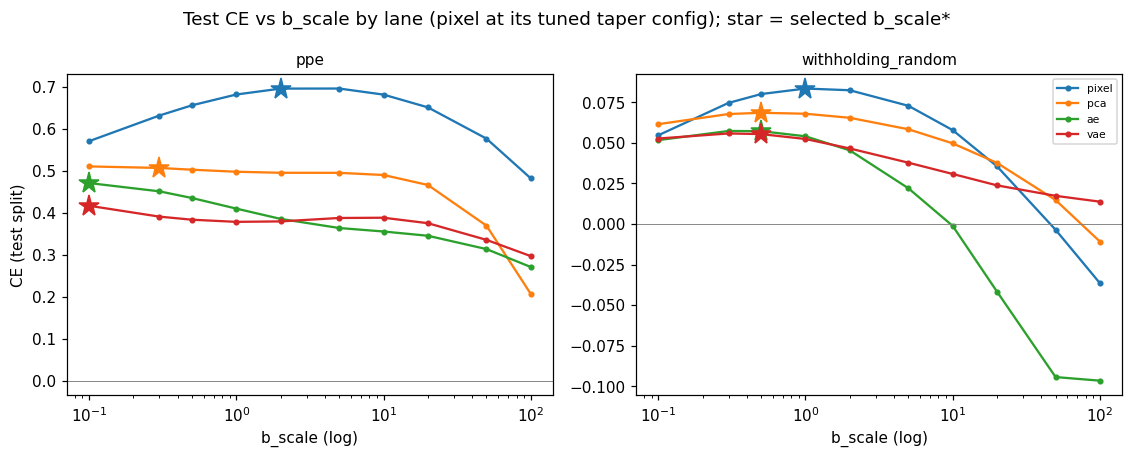

In [4]:
fig, axes = plt.subplots(1, len(LANES), figsize=(5.2 * len(LANES), 4.2), squeeze=False)
for ax, lane in zip(axes[0], LANES):
    base = M[(M.lane == lane) & (M.split == "test") & (M.method == "3dvar")
             & (M.channel == "pooled") & (M.do_event == "all") & (M.metric == "ce")
             & (M.fold == -1)]
    for m in ROW_ORDER:
        cfg = best[(m, lane)]
        g = match_taper(base[base.model == m], cfg).sort_values("b_scale")
        if g.empty:
            continue
        line, = ax.plot(g.b_scale, g.value, marker="o", ms=3, label=m)
        gb = g[np.isclose(g.b_scale, cfg["b_scale"])]
        if len(gb):
            ax.plot(gb.b_scale, gb.value, marker="*", ms=14, color=line.get_color())
    ax.set_xscale("log")
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlabel("b_scale (log)")
    ax.set_title(lane, fontsize=10)
axes[0, 0].set_ylabel("CE (test split)")
axes[0, -1].legend(fontsize=7)
fig.suptitle("Test CE vs b_scale by lane (pixel at its tuned taper config); star = selected b_scale*")
fig.tight_layout()
fig.savefig(FIG / "b_scale_sweep.png", bbox_inches="tight")
plt.show()

## PPE prior vs posterior

Does assimilation improve on the raw prior? On the PPE lane the prior is the flat
climatology field, so this is legible for SSIM and RRMSE (CE is redundant with its own
climatology baseline). Values at each model's PPE operating point, then three maps of the
tuned pixel model at its own b*.

- Per-cell CE across the truths: where the reconstruction has skill, with the union of
  assimilated sites overlaid (the network shape varies per truth).
- Realized error reduction: the per-cell drop in RMSE from the climatological first guess
  to the analysis. 1 where the analysis removes all background error, 0 where it does
  nothing, negative where it hurts.
- Claimed uncertainty reduction: diag A against diag B, the prior std scaled to b*. This
  is what the analysis says it achieved; the panel above is what it actually achieved.

,prior_rrmse,post_rrmse,prior_ssim,post_ssim,prior_rmse,post_rmse
model,,,,,,
pixel,1.0,0.552,0.361,0.693,1.158,0.639
pca,1.0,0.703,0.361,0.574,1.158,0.814
ae,1.0,0.728,0.361,0.518,1.158,0.843
vae,1.0,0.764,0.361,0.501,1.158,0.885


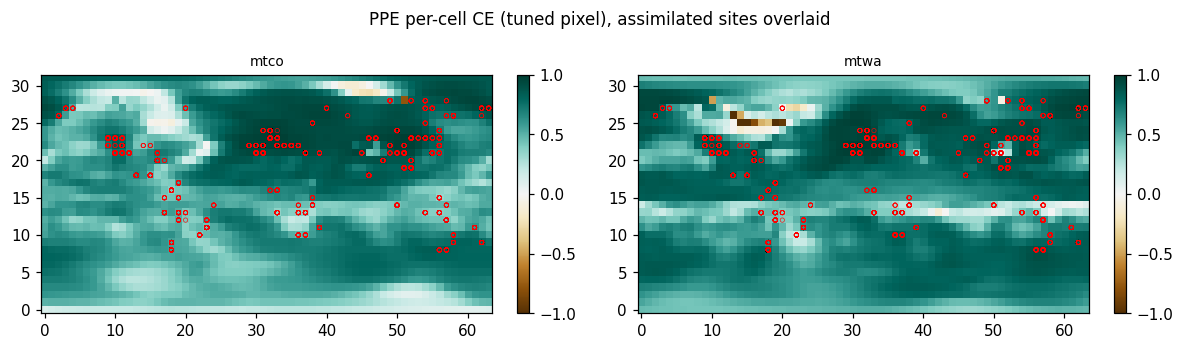

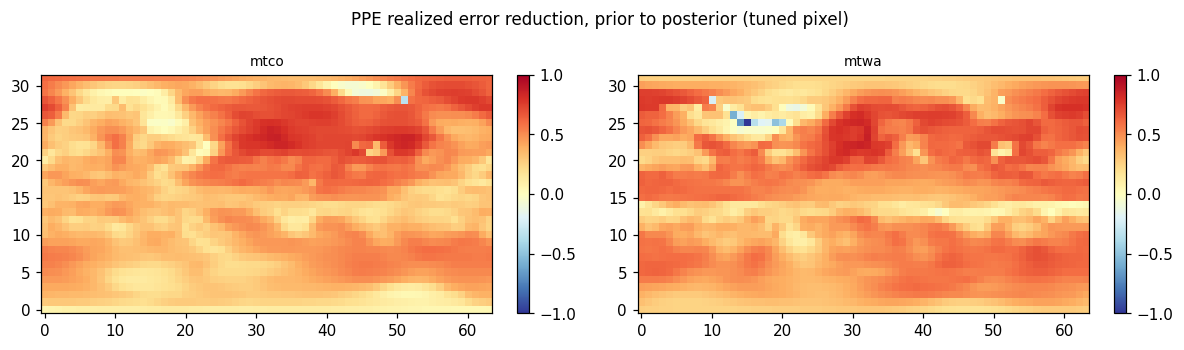

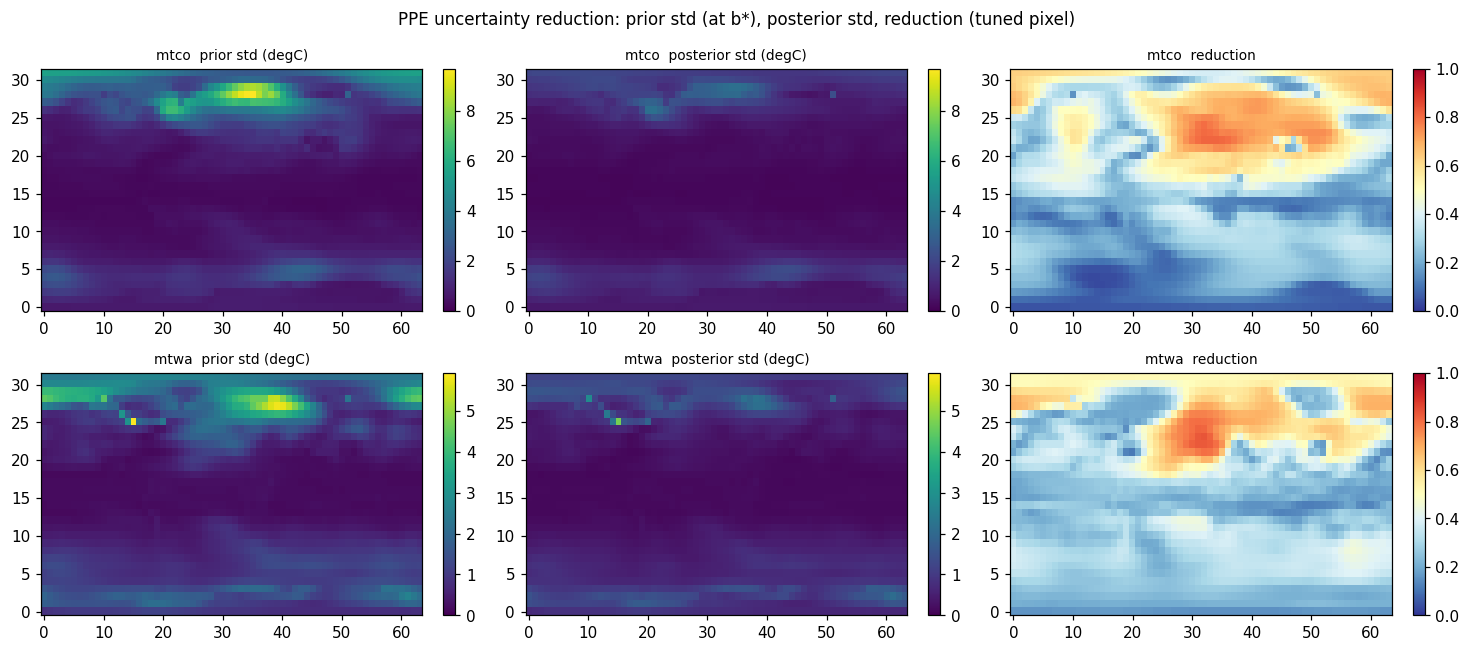

In [5]:
rows = []
for m in ROW_ORDER:
    if m not in MODEL_DIR:
        continue
    p = OUT / MODEL_DIR[m] / "ppe_analysis.npz"
    if not p.exists():
        continue
    z = np.load(p)
    truth, sv, bsc = z["truth_anom"], z["safe_valid"], z["b_scales"]
    b = best[(m, "ppe")]["b_scale"]
    recon = z["recon_climatological"][int(np.argmin(np.abs(bsc - b)))]
    prior = np.zeros_like(truth)
    t, r, pr = truth[:, :, sv], recon[:, :, sv], prior[:, :, sv]
    dr = [float(truth[:, c, sv].max() - truth[:, c, sv].min()) for c in range(truth.shape[1])]
    ssim = lambda f: float(np.mean([da.masked_ssim(truth[i, c], f[i, c], sv, dr[c])
                                    for i in range(len(truth)) for c in range(truth.shape[1])]))
    rows.append({"model": m, "prior_rrmse": da.relative_rmse(t, pr), "post_rrmse": da.relative_rmse(t, r),
                 "prior_ssim": ssim(prior), "post_ssim": ssim(recon),
                 "prior_rmse": da.rmse(t, pr), "post_rmse": da.rmse(t, r)})
pvp = pd.DataFrame(rows).set_index("model").reindex([m for m in ROW_ORDER if m in MODEL_DIR and
                                                     any(r["model"] == m for r in rows)])
display(pvp.round(3))

zr = np.load(OUT / "3dvar_pixel" / "ppe_analysis.npz")
br = best[("pixel", "ppe")]["b_scale"]
bir = int(np.argmin(np.abs(zr["b_scales"] - br)))
truth_p, sv_p = zr["truth_anom"], zr["safe_valid"]
recon_p = zr["recon_climatological"][bir]
mask_p = np.broadcast_to(sv_p, truth_p.shape[1:])


def assimilated_ij(chan):
    """Grid indices of every site assimilated in any test shape, for one channel.

    The network shape varies per truth, so the union across truths is the footprint
    the truth-aggregated maps are read against.
    """
    lat, lon = [], []
    for ti in range(len(zr["obs_n"])):
        nn = int(zr["obs_n"][ti])
        sel = zr["obs_chan"][ti, :nn] == chan
        lat.append(zr["obs_lat"][ti, :nn][sel])
        lon.append(zr["obs_lon"][ti, :nn][sel])
    return (nearest_lon_index(np.concatenate(lon), zr["lons"]),
            nearest_lat_index(np.concatenate(lat), zr["lats"]))


# Per-cell CE across the same-model truths: where the tuned pixel reconstruction has skill.
cem = da.ce_map(truth_p, recon_p, np.zeros_like(truth_p[0]))
fig = da.plot_skill_map(np.where(mask_p, cem, np.nan), VARS, cmap="BrBG", vmin=-1.0, vmax=1.0,
                        title="PPE per-cell CE (tuned pixel), assimilated sites overlaid")
# The colorbars are axes too, so select the map panels by the image they carry.
for ci, ax in enumerate(a for a in fig.axes if a.images):
    oj, oi = assimilated_ij(ci)
    ax.scatter(oj, oi, s=8, facecolors="none", edgecolors="red", linewidths=0.4)
fig.savefig(str(FIG / "ce_map_ppe_pixel.png"), dpi=110, bbox_inches="tight")
plt.show()

# Realized error reduction: the per-cell drop in RMSE from the climatological first guess.
red = da.error_reduction_map(truth_p, np.zeros_like(truth_p), recon_p)
da.plot_skill_map(np.where(mask_p, red, np.nan), VARS, vmin=-1.0, vmax=1.0,
                  title="PPE realized error reduction, prior to posterior (tuned pixel)",
                  save_path=str(FIG / "error_reduction_ppe_pixel.png"))
plt.show()

# The analysis at b_scale=b* runs against a prior scaled to b*.diagB, so the reduction
# must divide the posterior std by that same-b prior std (not the stored b_scale=1 std),
# else a b* != 1 biases the panel by sqrt(b*) and can show spurious negative reduction.
da.plot_prior_posterior_uncertainty(
    br * zr["prior_var"], zr["post_var"][bir].mean(axis=0), sv_p, VARS,
    title="PPE uncertainty reduction: prior std (at b*), posterior std, reduction (tuned pixel)",
    save_path=str(FIG / "uncertainty_reduction_ppe.png"))
plt.show()

## PPE skill vs distance to data

How far the reconstruction carries away from the proxies. Distance here is per **grid
cell**: the great-circle km from that cell to the nearest pseudo-observation in the
truth's network, so the curve covers the whole field rather than a set of sites. CE is
pooled over cells and truths within each bin, and every model sits at its own selected
b*.

This is the axis a generative prior is meant to improve, since a Gaussian update reverts
to the prior mean once the observations run out. The outermost bin runs against the
otherwise monotonic decay; it holds the few cells furthest from any pollen site, so read
it with caution rather than as part of the trend.

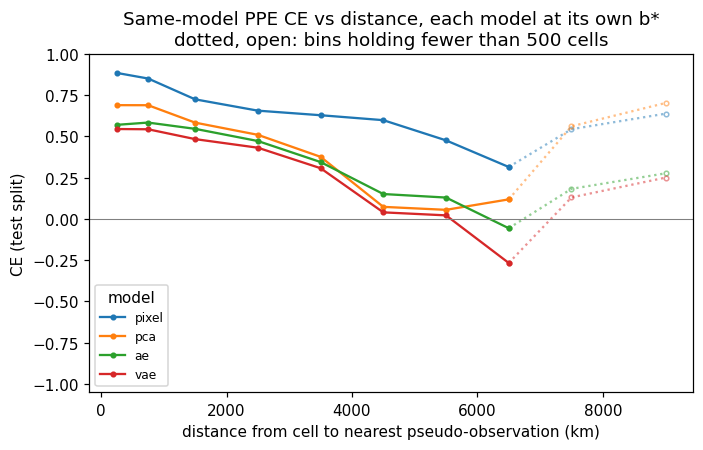

In [6]:
# The stored curve is binned at run time with a last edge of 20000 km, which draws that
# marker at a centre of 14000 km although no cell lies beyond ~9600 km. Rebuild the curve
# from the saved analysis fields instead, so the bin centres are honest and the decay
# between 3000 and 10000 km is resolved rather than hidden inside one wide bin.
DIST_EDGES = np.array([0, 500, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 10000],
                      dtype=float)
MIN_CELLS = 500        # thinner bins are drawn open and dotted rather than dropped


def ce_vs_distance(model):
    """Binned CE against distance to the nearest pseudo-observation, at the model's b*."""
    z = np.load(OUT / MODEL_DIR[model] / "ppe_analysis.npz")
    bi = int(np.argmin(np.abs(z["b_scales"] - best[(model, "ppe")]["b_scale"])))
    truth, recon, sv = z["truth_anom"], z["recon_climatological"][bi], z["safe_valid"]
    # The network shape varies per truth, so each truth carries its own distance field;
    # nearest_obs_distance returns it flat over the lat-major spatial axis.
    dist = np.stack([da.nearest_obs_distance(z["lats"], z["lons"],
                                             z["obs_lat"][t, :int(z["obs_n"][t])],
                                             z["obs_lon"][t, :int(z["obs_n"][t])])
                     for t in range(len(truth))])
    dpool = np.tile(dist[:, sv.ravel()], (1, truth.shape[1])).ravel()
    tpool = truth[:, :, sv].reshape(len(truth), -1).ravel()
    rpool = recon[:, :, sv].reshape(len(truth), -1).ravel()
    return da.skill_vs_distance(tpool, rpool, np.zeros_like(tpool), dpool, DIST_EDGES)


fig, ax = plt.subplots(figsize=(6.5, 4.2))
for m in ROW_ORDER:
    if m not in MODEL_DIR or not (OUT / MODEL_DIR[m] / "ppe_analysis.npz").exists():
        continue
    s = ce_vs_distance(m)
    c, ce, n = s["distance_km"], s["ce"], s["count"]
    solid = (n >= MIN_CELLS) & np.isfinite(ce)
    line, = ax.plot(c[solid], ce[solid], marker="o", ms=3, label=m)
    # The outermost bins hold a handful of polar cells; show them, but not as if the
    # upturn they produce were signal.
    thin = (n < MIN_CELLS) & (n > 0) & np.isfinite(ce)
    if thin.any():
        j = np.r_[np.flatnonzero(solid)[-1:], np.flatnonzero(thin)]
        ax.plot(c[j], ce[j], ls=":", marker="o", ms=3, mfc="none",
                color=line.get_color(), alpha=0.5)
ax.axhline(0, color="grey", lw=0.7)
ax.set_ylim(-1.05, 1.0)
ax.set_xlabel("distance from cell to nearest pseudo-observation (km)")
ax.set_ylabel("CE (test split)")
ax.legend(fontsize=8, title="model")
ax.set_title("Same-model PPE CE vs distance, each model at its own b*\n"
             f"dotted, open: bins holding fewer than {MIN_CELLS} cells")
fig.tight_layout()
fig.savefig(str(FIG / "ppe_skill_vs_distance.png"), dpi=110, bbox_inches="tight")
plt.show()

## Calibration: are the error bars honest?

Skill says how wrong each model was; this says whether it knew. Every model is at its own
selected operating point, on the disjoint `test` split.

- `crps` is an error in degC that scores the whole predictive distribution, not just its
  centre, so a confident-and-wrong forecast is punished harder than a vague one.
- `crpss` turns that into a skill score against the prior, exactly as CE does for squared
  error: 1 perfect, 0 no better than not assimilating.
- `rcrv_dispersion` is the error divided by the predicted uncertainty: 1 is honest, above
  1 overconfident, below 1 over-cautious.
- `coverage90` is the fraction of truths inside the stated 90% interval, so it should be
  0.9.

Against real proxies the predictive variance carries the proxy's own error and its
representativeness variance (`post_var + sse + rep_var`), because the residual holds all
three: a point proxy also deviates from the mean of its 5.625 degree grid cell, which no
grid-resolution reconstruction can predict. Against the noise-free PPE truth neither term
applies. The prior-free baselines carry no uncertainty and so have no rows here.

In [7]:
CAL_METRICS = ["crps", "crpss", "rcrv_dispersion", "coverage90"]


def calibration_table(channel="pooled"):
    """Calibration at each model's own b_scale*, test split, one column block per lane."""
    rows = {}
    for m in ROW_ORDER:
        rec = {}
        for lane in LANES:
            base = M[(M.model == m) & (M.lane == lane) & (M.split == "test")
                     & (M.channel == channel) & (M.do_event == "all") & (M.fold == -1)]
            sub = match_config(base, best[(m, lane)])
            for met in CAL_METRICS:
                v = sub[sub.metric == met]["value"]
                if len(v):
                    rec[(lane, met)] = float(v.iloc[0])
        if rec:
            rows[m] = rec
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows).T.reindex([m for m in ROW_ORDER if m in rows])
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    return df.round(3)


print("Pooled:")
display(calibration_table("pooled"))
for ch in VARS:
    print(ch)
    display(calibration_table(ch))

Pooled:


ppe                                   withholding_random         \
        crps  crpss rcrv_dispersion coverage90               crps  crpss   
pixel  0.277  0.437           0.783      0.970              1.048  0.044   
pca    0.388  0.234           3.146      0.507              1.055  0.035   
ae     0.438  0.212           5.037      0.319              1.063  0.028   
vae    0.453  0.139           4.346      0.356              1.066  0.027   

                                  
      rcrv_dispersion coverage90  
pixel           1.175      0.881  
pca             1.245      0.863  
ae              1.252      0.857  
vae             1.254      0.855

mtco


ppe                                   withholding_random         \
        crps  crpss rcrv_dispersion coverage90               crps  crpss   
pixel  0.275  0.462           0.626      0.987              1.257  0.060   
pca    0.296  0.426           2.213      0.578              1.271  0.050   
ae     0.360  0.364           3.997      0.367              1.280  0.044   
vae    0.385  0.283           3.834      0.391              1.282  0.042   

                                  
      rcrv_dispersion coverage90  
pixel           1.169      0.877  
pca             1.238      0.858  
ae              1.245      0.855  
vae             1.245      0.853

mtwa


ppe                                   withholding_random         \
        crps  crpss rcrv_dispersion coverage90               crps  crpss   
pixel  0.279  0.409           0.914      0.952              0.839  0.019   
pca    0.480  0.036           3.860      0.436              0.839  0.012   
ae     0.516  0.056           5.895      0.270              0.847  0.003   
vae    0.522 -0.012           4.803      0.321              0.851  0.003   

                                  
      rcrv_dispersion coverage90  
pixel           1.181      0.885  
pca             1.251      0.868  
ae              1.260      0.860  
vae             1.261      0.857

### Withholding calibration: the effect of representativeness variance

Recomputed from each model's withholding predictions at its own `b_scale*`, with the
predictive variance as `post_var + sse` (before) and `post_var + sse + rep_var` (after).
The point predictions are untouched, so skill is identical either way; only the stated
spread moves. Any over-coverage that survives is heavy-tailed innovation, not an
under-estimated variance.

In [8]:
from paleoreco.eval import calibration as cal


def rep_var_calibration(channel="pooled"):
    """Withholding coverage and dispersion with vs without rep_var, at each b_scale*.

    Recomputed from the predictions npz; the mean prediction is unchanged, so this
    isolates what the representativeness term does to the stated uncertainty.
    """
    rows = {}
    for m in ROW_ORDER:
        if m not in MODEL_DIR:
            continue
        p = OUT / MODEL_DIR[m] / "withholding_random_predictions.npz"
        if not p.exists():
            continue
        z = np.load(p)
        if "rep_var" not in z.files:
            continue
        bi = int(np.argmin(np.abs(z["b_scales"] - best[(m, "withholding_random")]["b_scale"])))
        a, pred, ch = z["actual"], z["climatological_pred"][bi], z["channel"]
        base = z["post_var_pred"][bi] + z["sse"]
        sel = np.ones(len(a), bool) if channel == "pooled" else ch == VARS.index(channel)
        a, pred = a[sel], pred[sel]
        before, after = base[sel], (base + z["rep_var"])[sel]
        rows[m] = {
            ("coverage90", "before"): cal.coverage(a, pred, before),
            ("coverage90", "after"): cal.coverage(a, pred, after),
            ("rcrv_dispersion", "before"): cal.rcrv(a, pred, before)[1],
            ("rcrv_dispersion", "after"): cal.rcrv(a, pred, after)[1],
        }
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows).T
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    return df.round(3)


print("Withholding calibration without vs with rep_var (coverage target 0.90, dispersion 1.0):")
print("Pooled:")
display(rep_var_calibration("pooled"))
for ch in VARS:
    print(ch)
    display(rep_var_calibration(ch))

Withholding calibration without vs with rep_var (coverage target 0.90, dispersion 1.0):
Pooled:


coverage90        rcrv_dispersion       
          before  after          before  after
pixel      0.779  0.881           1.651  1.175
pca        0.736  0.863           1.863  1.245
ae         0.733  0.857           1.875  1.252
vae        0.733  0.855           1.874  1.254

mtco


coverage90        rcrv_dispersion       
          before  after          before  after
pixel      0.710  0.877           1.907  1.169
pca        0.658  0.858           2.196  1.238
ae         0.657  0.855           2.209  1.245
vae        0.656  0.853           2.207  1.245

mtwa


coverage90        rcrv_dispersion       
          before  after          before  after
pixel      0.849  0.885           1.348  1.181
pca        0.815  0.868           1.456  1.251
ae         0.809  0.860           1.467  1.260
vae        0.810  0.857           1.469  1.261

## PPE field gallery

Reconstructed 2-D fields for every algorithm on three regime-spanning same-model truths
(coldest/stadial, median/transition, warmest/interstadial by global-mean anomaly). Per
model: rows are the three truths, columns are truth / posterior / error for each
channel, with the assimilated test-shape proxy sites overlaid. Posterior is at the
model's PPE `b_scale*`; the naive baselines are prior-free interpolations.

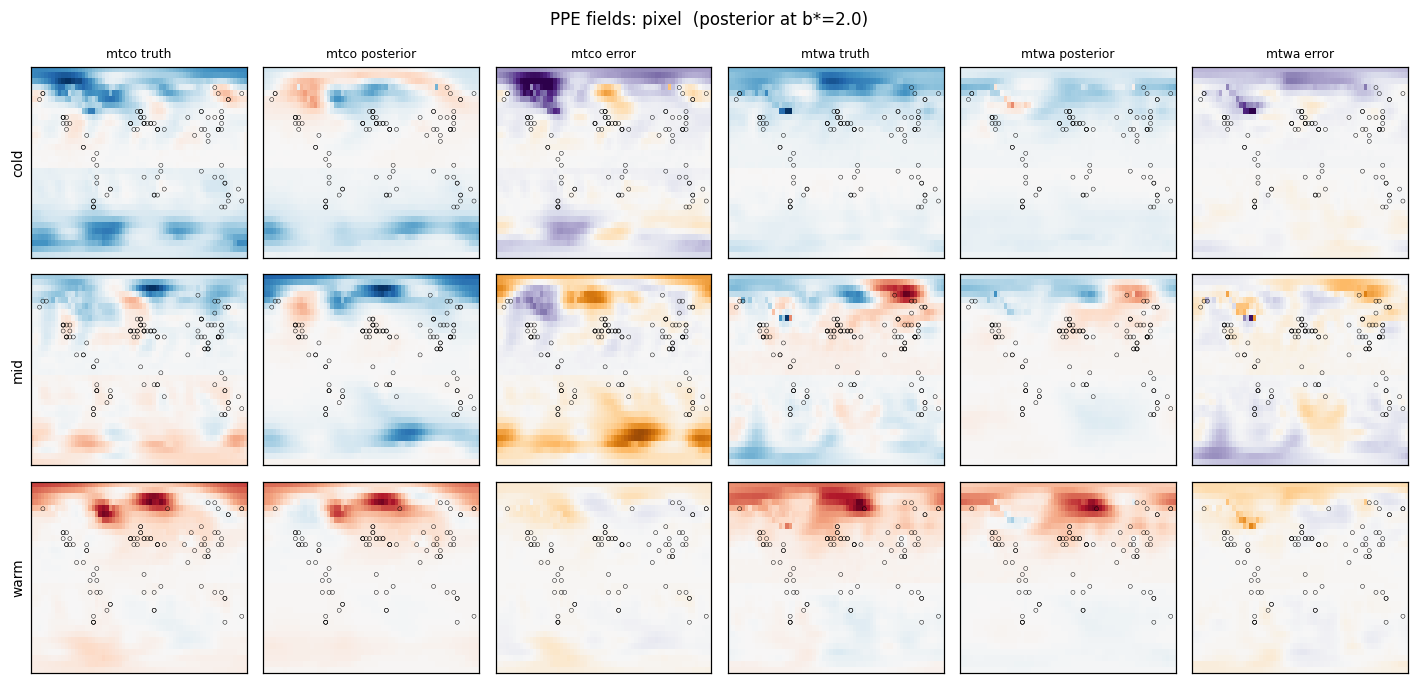

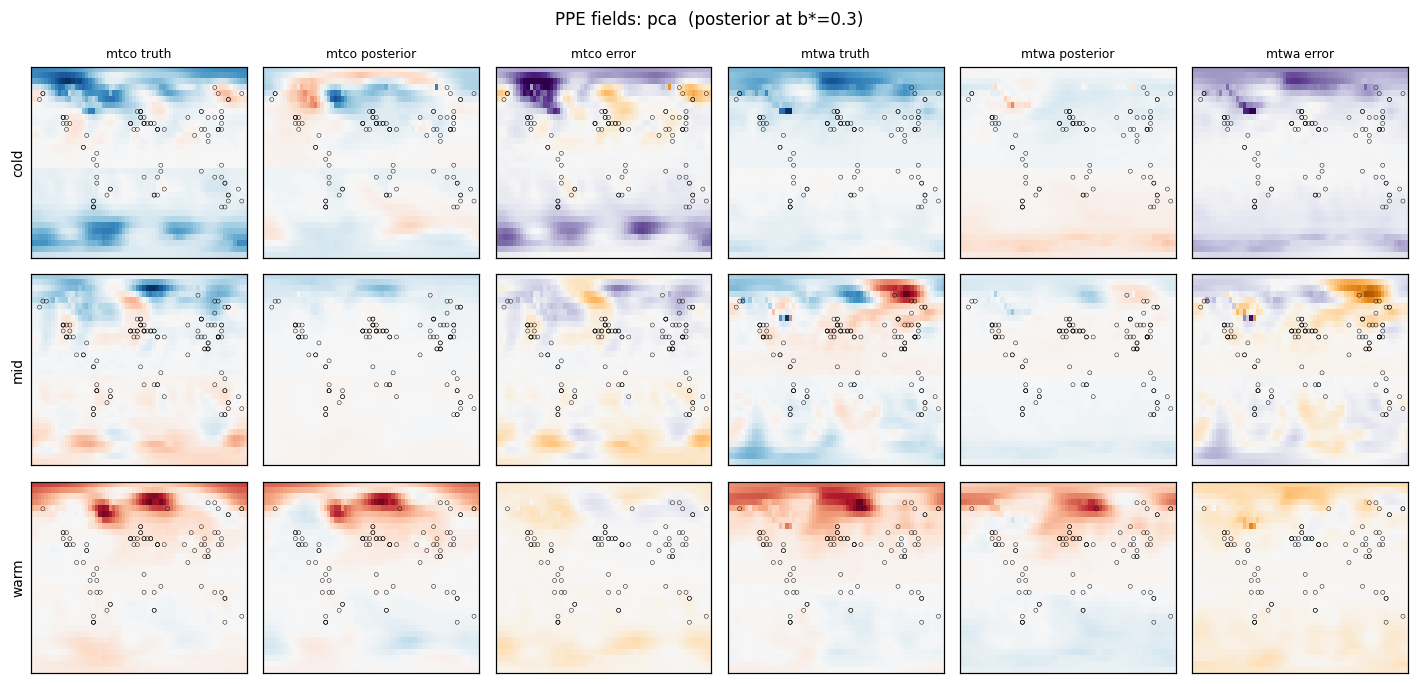

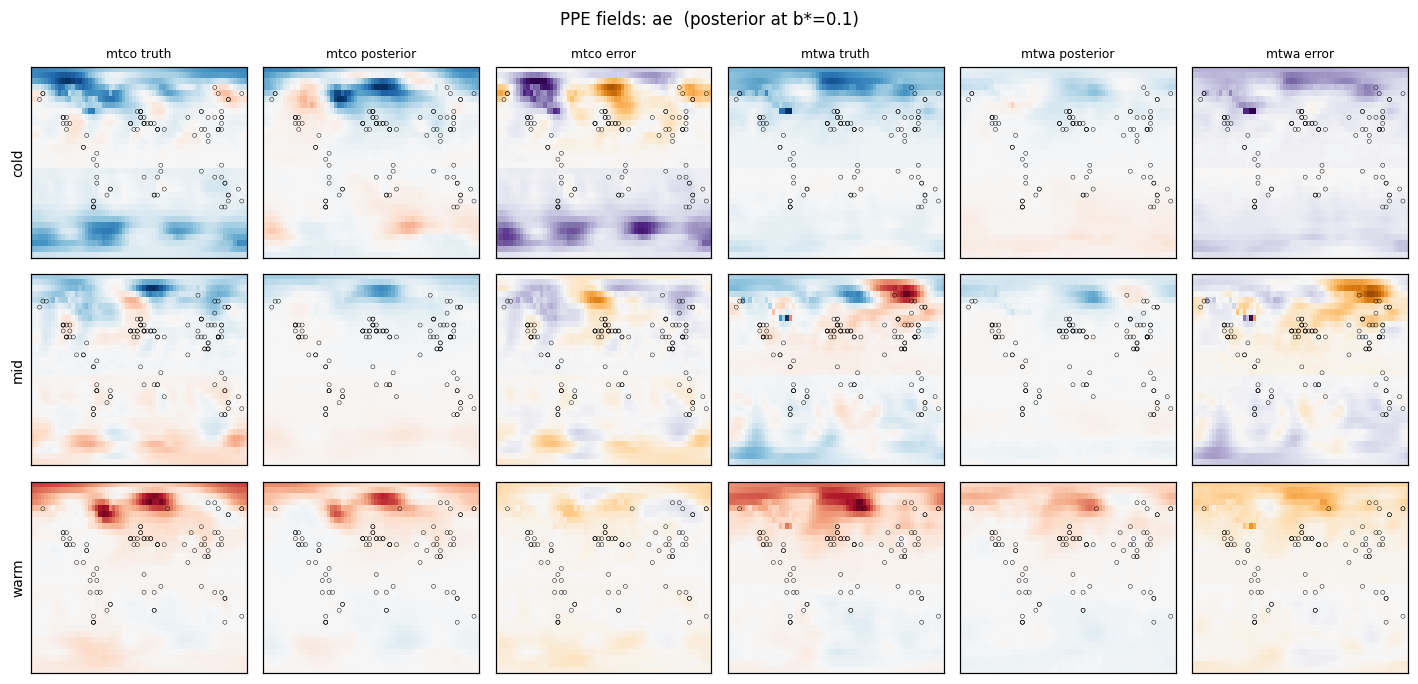

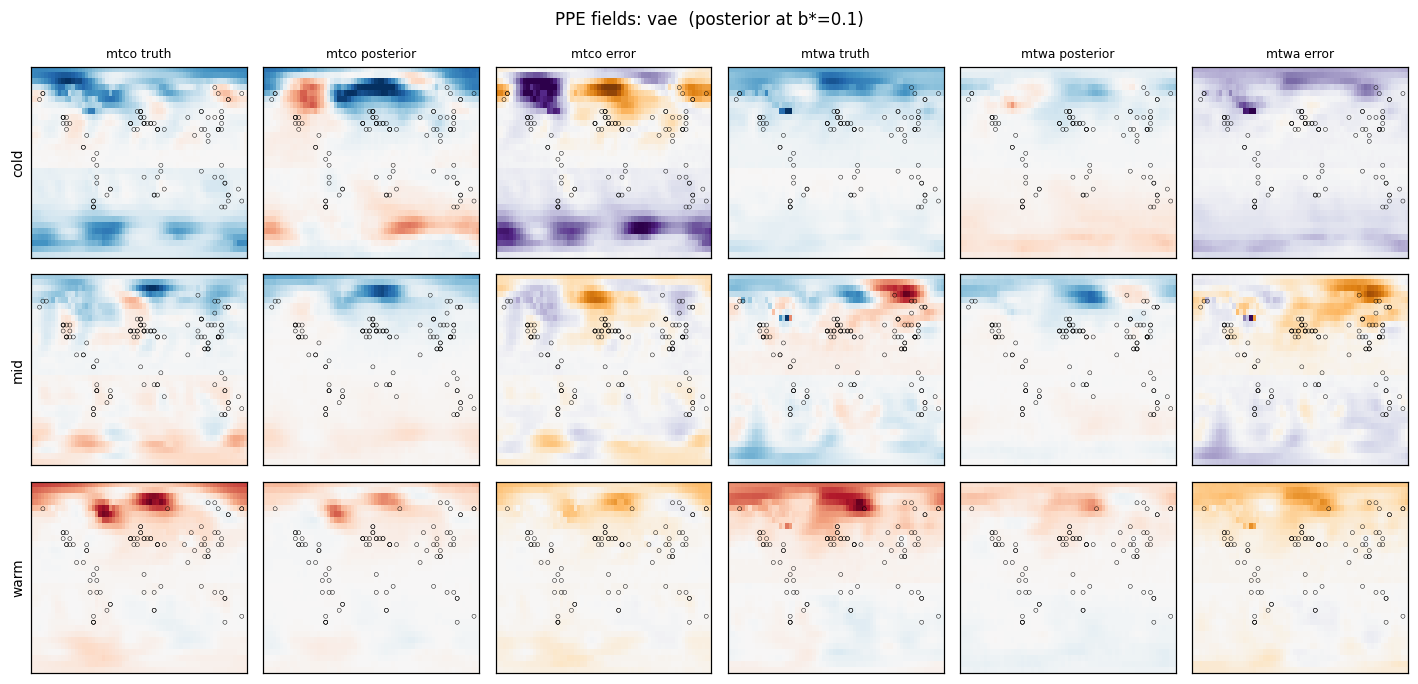

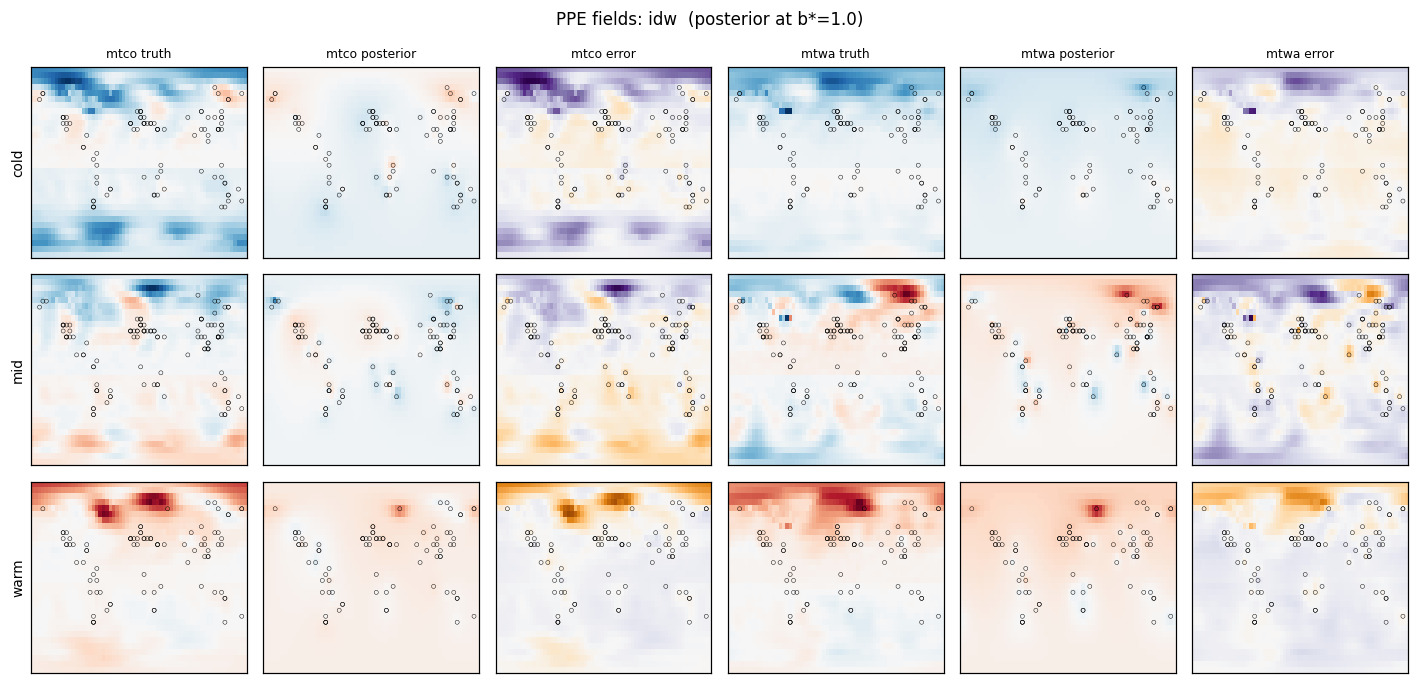

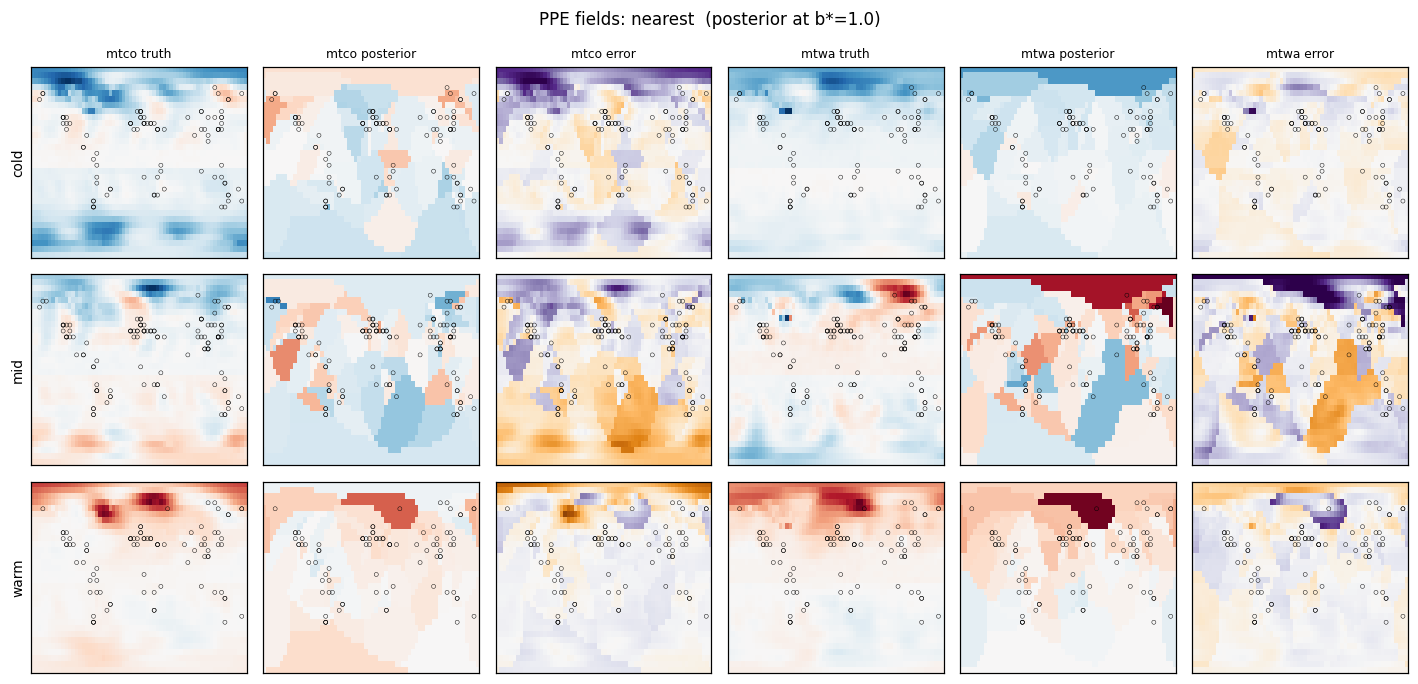

In [9]:
z0 = np.load(OUT / "3dvar_pixel" / "ppe_analysis.npz")
truth_g, sv_g = z0["truth_anom"], z0["safe_valid"]
lats_g, lons_g = z0["lats"], z0["lons"]
gm = truth_g[:, :, sv_g].mean(axis=(1, 2))               # per-truth global-mean anomaly
order = np.argsort(gm)
picks = [int(order[0]), int(order[len(order) // 2]), int(order[-1])]
plabels = ["cold", "mid", "warm"]

recons = {}
for m in MODEL_DIR:
    p = OUT / MODEL_DIR[m] / "ppe_analysis.npz"
    if p.exists():
        z = np.load(p)
        b = best[(m, "ppe")]["b_scale"]
        recons[m] = z["recon_climatological"][int(np.argmin(np.abs(z["b_scales"] - b)))]
recons["idw"] = z0["naive_idw"]
recons["nearest"] = z0["naive_nearest"]


def obs_ij(ti, ci):
    nn = int(z0["obs_n"][ti])
    sel = z0["obs_chan"][ti, :nn] == ci
    return (nearest_lon_index(z0["obs_lon"][ti, :nn][sel], lons_g),
            nearest_lat_index(z0["obs_lat"][ti, :nn][sel], lats_g))


for m in [x for x in ROW_ORDER if x in recons]:
    fig, axes = plt.subplots(len(picks), 6, figsize=(13, 2.1 * len(picks)), squeeze=False)
    for ri, ti in enumerate(picks):
        for ci, ch in enumerate(VARS):
            vlim = float(np.nanmax(np.abs(np.where(sv_g, truth_g[ti, ci], np.nan))) + 1e-9)
            oj, oi = obs_ij(ti, ci)
            panels = [("truth", truth_g[ti, ci], "RdBu_r", vlim),
                      ("posterior", recons[m][ti, ci], "RdBu_r", vlim),
                      ("error", recons[m][ti, ci] - truth_g[ti, ci], "PuOr", vlim)]
            for pi, (name, fld, cmap, vl) in enumerate(panels):
                ax = axes[ri, ci * 3 + pi]
                ax.imshow(np.where(sv_g, fld, np.nan), origin="lower", cmap=cmap,
                          vmin=-vl, vmax=vl, aspect="auto")
                ax.scatter(oj, oi, s=7, facecolors="none", edgecolors="k", linewidths=0.3)
                if ri == 0:
                    ax.set_title(f"{ch} {name}", fontsize=8)
                if ci == 0 and pi == 0:
                    ax.set_ylabel(plabels[ri], fontsize=9)
                ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"PPE fields: {m}  (posterior at b*={best[(m, 'ppe')]['b_scale']})", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG / f"ppe_gallery_{m}.png", dpi=110, bbox_inches="tight")
    plt.show()